# ALeRCE LSST, TAP queries

```Author: Alejandra Muñoz Arancibia. Last updated: 260825```

This notebook shows how to query the Rubin alert stream data (as well as derived properties) stored by the ALeRCE broker. We show examples of queries to our database via the ALeRCE Table Access Protocol (TAP) service, using the pyvo package to execute Astronomical Data Query Language (ADQL) queries and the pandas package to manipulate output tables as dataframes.

We refer to [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Tables.ipynb) for a detailed description of how Rubin data are stored in the ALeRCE multistream database. In the present notebook we also show a brief example of how to query alert image cutouts (hereafter "stamps") using the ALeRCE python client, which is described in more detail in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb).

*It is highly recommended that you try this notebook in Google Colab using the following [link](https://colab.research.google.com/github/alercebroker/usecases/blob/master/notebooks/LSST/ALeRCE_LSST_TAP_Queries.ipynb).* This will avoid you from having to sort out library installation problems and focus on the contents of the tutorial. You can try installing the dependencies later in your own system.

# Table of contents

* [Before starting](#before)
    * [Some settings](#settings)
    * [Initialize the ALeRCE client](#client)
    * [LSST queries to the ALeRCE multisurvey database](#multisurvey)
    * [Types of object identifiers](#sid)
    * [Connect to ALeRCE data via TAP](#tap)
* [How to query individual objects](#query_one)
    * [Query a diaObject](#query_diaobject)
        * [Basic statistics](#object_one)
        * [Light curves](#light_curves)
        * [Stamps](#stamps)
        * [Latest diaObject information](#diaobject_latest)
    * [Query a ssObject](#query_ssobject)
        * [Epoch data from the ssSource alert field, and latest mpc_orbits information](#tables_sso)
    * [Cone search](#conesearch)
* [Querying samples of objects](#query_many)
    * [Generate an ALeRCE LSST Explorer link](#explorer_url)
    * [Object lists](#query_list)
    * [Querying detections for larger samples](#query_detections_many)

## Before starting <a class='anchor' id='before'></a>

### Some settings <a class='anchor' id='settings'></a>

In this notebook we use the [ALeRCE python client](https://alerce.readthedocs.io/en/latest/) to retrieve alert stamps. Install the ALeRCE python client uncommenting the following line. In case you have a previous alerce package version, note that you need to update it to version 2.2.1 or newer to retrieve Rubin data.

In [1]:
#!pip install alerce

We also use custom functions defined in ```lib_multisurvey```. In case you are using Google Colab, download this uncommenting the following line.

In [2]:
#!wget https://raw.githubusercontent.com/alercebroker/usecases/master/notebooks/LSST/lib_multisurvey/alerce_multisurvey_tools.py -P lib_multisurvey/

Load libraries

In [3]:
#!pip install pyvo

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18
from astropy.time import Time
import pyvo
import sys

In [5]:
from alerce.core import Alerce

In [6]:
from IPython.core.display import HTML
pd.set_option('display.max_colwidth', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

### Initialize the ALeRCE client <a class='anchor' id='client'></a>

In [7]:
alerce_client = Alerce()

### LSST queries to the ALeRCE multisurvey database <a class='anchor' id='multisurvey'></a>

We save Rubin alert stream data in a multisurvey database. We distinguish among data sources by using the field ```tid```, for "telescope identifier". LSST (and more generally, all Rubin data observed with the Simonyi telescope) has ```tid = 1```.

In [8]:
tid = 1

### Types of object identifiers <a class='anchor' id='sid'></a>

In LSST alerts, astrophysical objects have different identifiers depending on what they are associated to. Non-moving objects (e.g. supernovae, active galactic nuclei, variable stars) are associated to diaObjects, while known Solar System moving objects (e.g. asteroids) are associated to ssObjects. Identifiers for diaObjects and ssObjects are generated independent of each other by the LSST pipelines. We distinguish among them using the field ```sid```, for "survey identifier".

We use the field ```oid``` as the identifier for each object. This ```oid``` is defined in different ways depending on the availability of diaObject information in the alert, so that

```oid = diaObjectId``` and ```sid = 1``` for objects that have diaObject information, and

```oid = ssObjectId``` and ```sid = 2``` if they only have ssObject information. In case an object has both identifiers (e.g. a known Solar System object was identified at a small angular distance from a non-moving object), we adopt ```oid = diaObjectId``` and ```sid = 1``` while still saving both their diaObject and ssObject data in the respective tables.

We call the identifier for each epoch in every survey as ```measurement_id```. For LSST, this means both field ```diaSourceId``` for detections and field ```diaForcedSourceId``` for forced photometry points are renamed ```measurement_id``` in our database. We also rename the mid-visit time for each epoch from field ```midpointMjdTai``` to ```mjd```.

### Connect to ALeRCE data via TAP <a class='anchor' id='tap'></a>

We connect to the ALeRCE multisurvey database using [ADQL](https://www.ivoa.net/documents/ADQL/) queries to the [ALeRCE TAP service](https://tap.alerce.online/), returning results as pandas dataframes. Database table names are prefixed with `alerce_tap.` (e.g. `alerce_tap.object`, `alerce_tap.detection`, etc.).

In [9]:
TAP_URL = 'https://tap.alerce.online/tap'
tap_service = pyvo.dal.TAPService(TAP_URL)

def tap_query(query, maxrec=10_000_000):
    result = tap_service.search(query, maxrec=maxrec)
    return result.to_table().to_pandas()

## How to query individual objects <a class='anchor' id='query_one'></a>

Here we illustrate three examples of object queries: 1) a diaObject, 2) a ssObject, and 3) a cone search. The first two cases are useful when the object identifier is known, while the third is useful to explore LSST data for an object from an external catalog whose equatorial coordinates are known. Along these examples we show how to query several properties, like basic statistics, light curves, and stamps.

### Query a diaObject <a class='anchor' id='query_diaobject'></a>

We choose ```oid = diaObjectId = 313853496686280764```, which can be found in the ALeRCE LSST Explorer as https://lsst.alerce.online/object/313853496686280764?survey=lsst. This object was reported to the [Transient Name Server](https://www.wis-tns.org/) based on ATLAS detections ([Tonry et al. 2025](https://www.wis-tns.org/object/2025agtf/discovery-cert)) and received the IAU name [AT 2025agtf](https://www.wis-tns.org/object/2025agtf). According to NED, its tentative host (WISEA J003724.47-422751.5) has redshift $z = 0.070493$.

In [10]:
oid = 313853496686280764
sid = 1
z_obj = 0.070493

#### Basic statistics <a class='anchor' id='object_one'></a>

We query the main properties of this object as

In [11]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    oid = %d
    AND sid = %d
''' % (oid, sid)

df_obj = tap_query(query)
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,313853496686280764,1,1,9.35233,-42.462751,1.279001e-07,1.209322e-07,61024.13142,61233.40148,209.27006,73,25,0,2026-02-13,2026-07-12


#### Light curves <a class='anchor' id='light_curves'></a>

We obtain its light curve (detections and forced photometry points) by querying tables ```detection```, ```lsst_detection```, ```forced_photometry``` and ```lsst_forced_photometry```, and joining them on ```(oid, sid, measurement_id)```

In [12]:
query = '''
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.oid = %d
    AND det.sid = %d
''' % (oid, sid)
df_dets = tap_query(query)

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_dets.drop(columns=cols, inplace=True)
display(df_dets)

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trailalgorithm,trail_flag,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,reliabilityversion,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,exposuretime,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp
0,313853496686280764,1,170587116599771287,61217.416228,9.352328,-42.462762,3,2026-06-26,0,2026062500645,6,313853496686280764,0,0.000019,0.000020,4.420417e-11,1464.210693,0.333903,968.741089,0.376710,False,-4991.619629,589.526611,False,False,True,16.631289,-3079.354004,182.276062,NaN,1880.859497,1681,False,False,False,-3312.952148,183.474686,9.352332,NaN,-42.462764,NaN,0.988732,0.209040,176.621475,13.596715,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3734.666260,181.887939,False,False,False,6918.814941,65.218552,0.183728,0.201009,0.049316,0.102191,0.109693,0.012912,False,False,False,False,0.829133,0.606399,,False,False,61217.418142,NaN,NaN,17,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,313853496686280764,1,170587117138214978,61217.420025,9.352314,-42.462750,1,2026-06-26,0,2026062500649,9,313853496686280764,0,0.000007,0.000009,4.072209e-12,421.742767,0.125876,2665.006104,0.161196,False,1467.178101,272.745911,False,False,False,21.068914,2097.841064,99.476677,NaN,1877.271729,1681,False,False,False,2014.229370,63.781933,9.352314,NaN,-42.462750,NaN,0.557504,0.234841,15.920236,25.409292,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,3776.471191,100.853874,False,False,False,1597.849854,33.828625,0.110753,0.136963,-0.003952,0.117105,0.153027,0.006810,False,False,False,False,0.023024,0.786226,,False,False,61217.421427,NaN,NaN,17,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,313853496686280764,1,170657517458161746,61233.399660,9.352299,-42.462764,3,2026-07-12,0,2026071100884,75,313853496686280764,0,0.000018,0.000018,-1.482970e-13,2074.844971,0.323735,577.093262,0.327490,False,-3528.104004,602.205139,False,False,True,13.382581,-3406.018311,254.188156,NaN,1645.945557,1681,False,False,False,-3295.316650,224.729919,9.352299,NaN,-42.462766,NaN,0.893750,0.444343,-140.789520,30.671530,NaN,0,1,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,6157.629883,259.071533,False,False,False,9608.153320,29.890341,0.261249,0.247742,0.034598,0.199355,0.198726,0.009906,False,False,False,False,0.321158,0.525943,0.3,False,False,61233.401419,NaN,NaN,20,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,313853496686280764,1,170657517570359340,61233.401480,9.352342,-42.462741,1,2026-07-12,0,2026071100885,33,313853496686280764,0,0.000014,0.000015,-8.240756e-12,3138.43

In [13]:
query = '''
SELECT
    forced.*,
    lsst_forced.*
FROM
    alerce_tap.forced_photometry AS forced
JOIN
    alerce_tap.lsst_forced_photometry AS lsst_forced
ON
    forced.oid = lsst_forced.oid
    AND forced.sid = lsst_forced.sid
    AND forced.measurement_id = lsst_forced.measurement_id
WHERE
    forced.oid = %d
    AND forced.sid = %d
''' % (oid, sid)
df_forced = tap_query(query)

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_forced.drop(columns=cols, inplace=True)
display(df_forced)

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,visit,detector,psfflux,psffluxerr,scienceflux,sciencefluxerr,timeprocessedmjdtai,timewithdrawnmjdtai
0,313853496686280764,1,170587116599771137,61217.416228,9.35233,-42.462751,3,2026-06-26,2026062500645,6,-3120.505371,184.691116,3710.678711,181.853668,61217.418249,NaN
1,313853496686280764,1,170587116732416003,61217.416705,9.35233,-42.462751,3,2026-07-12,2026062500646,3,-3095.134521,190.848648,3853.306885,188.723526,61217.418731,NaN
2,313853496686280764,1,170587117138214918,61217.420025,9.35233,-42.462751,1,2026-06-26,2026062500649,9,2137.967041,101.690491,3762.222656,100.803078,61217.421474,NaN
3,313853496686280764,1,170587117274529797,61217.420491,9.35233,-42.462751,1,2026-07-12,2026062500650,13,2098.656006,98.275085,3688.980713,97.854111,61217.421897,NaN
4,313853496686280764,1,170595944404353032,61219.418592,9.35233,-42.462751,3,2026-07-12,2026062700881,75,-3335.750488,462.655670,10570.150391,462.645782,61219.420524,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,313853496686280764,1,170648691567755272,61231.362938,9.35233,-42.462751,3,2026-07-12,2026070900662,73,-3073.975830,1729.403931,4584.967773,1732.558960,61231.364775,NaN
21,313853496686280764,1,170648691681525769,61231.363374,9.35233,-42.462751,3,2026-07-12,2026070900663,34,-5627.153320,2022.555176,1440.255127,2032.123169,61231.365158,NaN
22,313853496686280764,1,170648700285616138,61231.400081,9.35233,-42.462751,2,2026-07-12,2026070900727,61,1873.186035,412.994476,7014.694824,411.194855,61231.401477,NaN
23,313853496686280764,1,170657517458161668,61233.399660,9.35233,-42.462751,3,2026-07-12,2026071100884,75,-3463.660400,260.591034,6034.119141,259.030518,61233.401522,NaN


Note that we use integer identifiers for LSST bands. We recover the original band names using the mapping defined in the ```band``` lookup table (LUT)

In [14]:
table_name = 'band'

query = '''
SELECT
    sid, tid, band, band_name, band_order
FROM
    alerce_tap.%s
WHERE
    tid = %d
ORDER BY
    sid ASC, band_order ASC
''' % (table_name, tid)

df_bands = tap_query(query)
display(df_bands)

,sid,tid,band,band_name,band_order
0,1,1,6,u,0
1,1,1,1,g,1
2,1,1,2,r,2
3,1,1,3,i,3
4,1,1,4,z,4
5,1,1,5,y,5
6,2,1,6,u,0
7,2,1,1,g,1
8,2,1,2,r,2
9,2,1,3,i,3


We create a function to apply the mapping between columns, useful for also other LUTs in this notebook

In [15]:
def add_mapped_column(df=None, df_lut=None,
                      col=None, col_mapped=None):
    def map_column(row):
        row_index = (row['sid'], row[col]) \
                    if 'sid' in df_lut.columns \
                    else row[col]
        col_new = df_aux.loc[
            row_index, col_mapped] \
            if row_index in df_aux.index \
            else None
        return col_new
    
    df = df.copy()

    if len(df) > 0:
        row_index = ['sid', col] if 'sid' in df_lut.columns else col
        df_aux = df_lut.set_index(row_index).copy()
        
        df[col_mapped] = df.apply(
            lambda row: map_column(row),
            axis=1)
    else:
        df[col_mapped] = None

    return df

In [16]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

df_forced = add_mapped_column(
    df=df_forced,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
if len(df_forced) > 0:
    df_forced.set_index('oid', inplace=True)

We display the columns that will be used to build the light curve. In this particular case, the object does not have forced photometry data

In [17]:
cols_lc = ['sid', 'measurement_id', 'band_name', 'mjd',
        'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr']
cols_lc = [x.lower() for x in cols_lc]
display(df_dets[cols_lc])
display(df_forced[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
313853496686280764,1,170587116599771287,i,61217.416228,-3079.354004,182.276062,3734.666260,181.887939
313853496686280764,1,170587117138214978,g,61217.420025,2097.841064,99.476677,3776.471191,100.853874
313853496686280764,1,170657517458161746,i,61233.399660,-3406.018311,254.188156,6157.629883,259.071533
313853496686280764,1,170657517570359340,g,61233.401480,1737.205322,117.398911,4467.497070,119.216972
313853496686280764,1,313853496686280764,i,61024.131420,69393.812500,434.881348,87073.445312,451.603729
...,...,...,...,...,...,...,...,...
313853496686280764,1,314011736304779269,z,61060.078867,77321.289062,601.811462,83513.789062,595.499695
313853496686280764,1,314011736438997002,z,61060.079265,71776.125000,610.012024,79541.820312,613.229431
313853496686280764,1,314011736707432455,z,61060.080660,77316.828125,598.632751,84569.539062,598.704407


,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
313853496686280764,1,170587116599771137,i,61217.416228,-3120.505371,184.691116,3710.678711,181.853668
313853496686280764,1,170587116732416003,i,61217.416705,-3095.134521,190.848648,3853.306885,188.723526
313853496686280764,1,170587117138214918,g,61217.420025,2137.967041,101.690491,3762.222656,100.803078
313853496686280764,1,170587117274529797,g,61217.420491,2098.656006,98.275085,3688.980713,97.854111
313853496686280764,1,170595944404353032,i,61219.418592,-3335.750488,462.655670,10570.150391,462.645782
...,...,...,...,...,...,...,...,...
313853496686280764,1,170648691567755272,i,61231.362938,-3073.975830,1729.403931,4584.967773,1732.558960
313853496686280764,1,170648691681525769,i,61231.363374,-5627.153320,2022.555176,1440.255127,2032.123169
313853496686280764,1,170648700285616138,r,61231.400081,1873.186035,412.994476,7014.694824,411.194855


We count the number of detections per band for this object

In [18]:
display(df_dets['band_name'].value_counts())

band_name
i    22
r    20
z    20
g    11
Name: count, dtype: int64

We show this light curve using a custom function defined in ```lib_multisurvey```

In [19]:
sys.path.append('./lib_multisurvey')
import alerce_multisurvey_tools as ms

We define some dictionaries to customize how to show the light curves. We will show both difference and science fluxes, including detections and (when available) forced photometry epochs 

In [20]:
# More parameters (and their default values) defined in
# lib_multisurvey/alerce_multisurvey_tools.py, function plot_lc
lc_params = {
    'from_tap': True,
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [21]:
epochs = {
    'detections': df_dets,
    'forced_photometry': df_forced,
}

d_objs = ms.group_data_sid_oid(
    sid=sid,
    oid=oid,
    df_dets=epochs['detections'].copy(),
    df_forced=epochs['forced_photometry'].copy() \
        if oid in epochs['forced_photometry'].index else pd.DataFrame(),
    lc_kwargs=ms.init_lc_kwargs()
)

We show the light curves

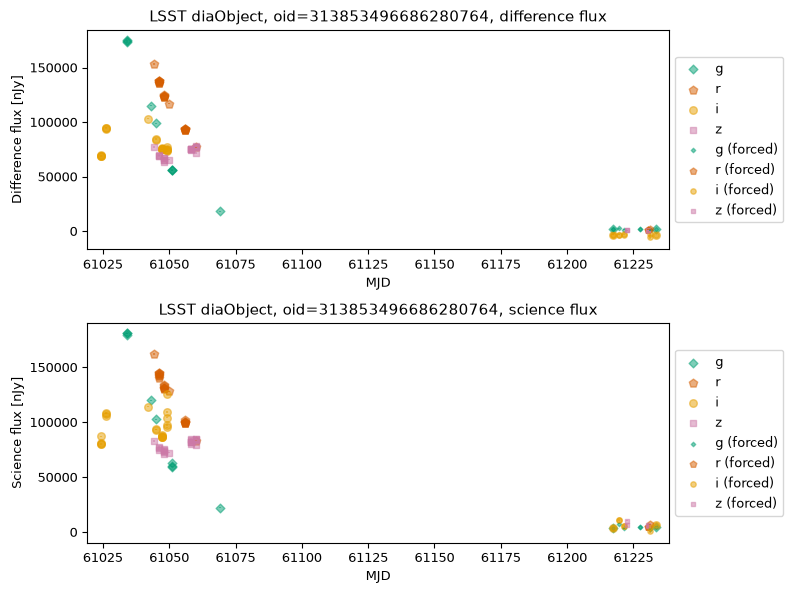

In [22]:
d_objs[sid][oid]['lc_kwargs']['show_forced'] = True

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

We can show these light curves using magnitude units

/home/ammunoz1/.local/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


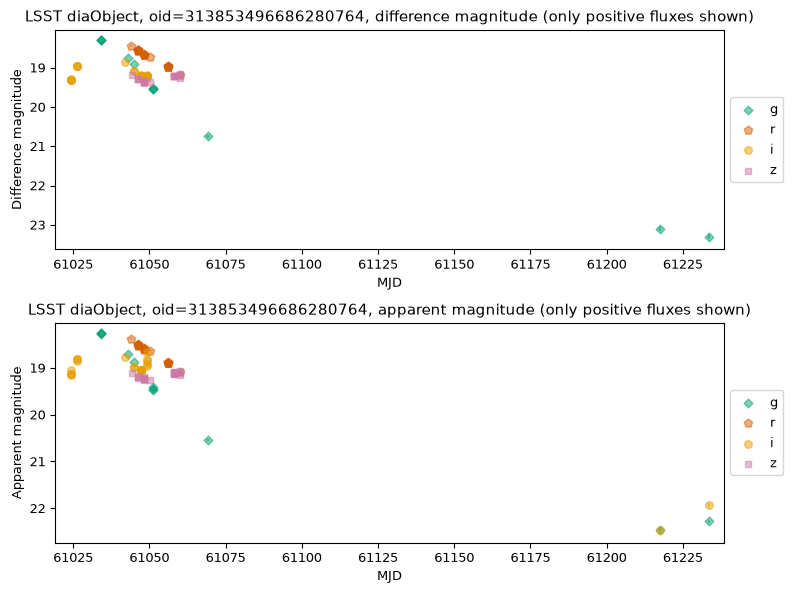

In [23]:
d_objs[sid][oid]['lc_kwargs']['show_flux'] = False
d_objs[sid][oid]['lc_kwargs']['show_forced'] = False

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

We can also show them using absolute magnitudes, assuming the redshift of the tentative host and the Planck 2018 cosmology

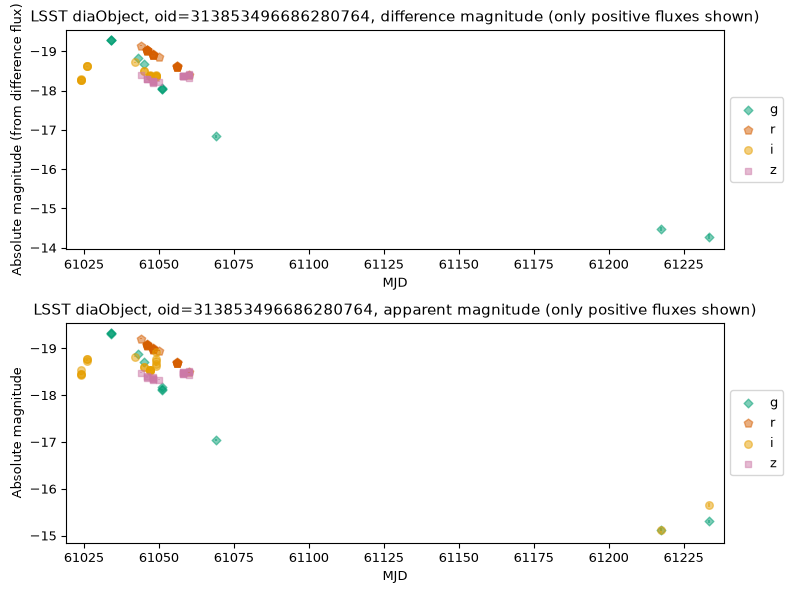

In [24]:
d_objs[sid][oid]['lc_kwargs']['show_absolute_mag'] = True
d_objs[sid][oid]['lc_kwargs']['z_obj'] = z_obj
d_objs[sid][oid]['lc_kwargs']['cosmo'] = Planck18

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

#### Stamps <a class='anchor' id='stamps'></a>

We show alert image cutouts for the first three detections of this object that triggered alerts. Note that not all stored detections may have triggered an alert, as they may come in an alert as previous detections. The field ```has_stamp``` in our detections dataframe indicates that a given detection triggered an alert, so that we can use it as a mask as

In [25]:
mask = epochs['detections']['has_stamp']
df_dets_this = epochs['detections'][mask].sort_values(by='mjd').iloc[0:3].copy()

cols = ['sid', 'measurement_id', 'band_name', 'mjd',
        'psfFlux', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr',
        'has_stamp']
cols = [x.lower() for x in cols]
display(df_dets_this[cols])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr,has_stamp
oid,,,,,,,,,
313853496686280764,1,313853496686280764,i,61024.131420,69393.812500,434.881348,87073.445312,451.603729,True
313853496686280764,1,313853498027933784,i,61024.138132,68777.632812,369.121277,80362.007812,372.005737,True
313853496686280764,1,313853498568474633,i,61024.140180,68613.234375,369.339661,79989.171875,374.356750,True


We use the ALeRCE client to retrieve the stamps, obtaining the main fields: Science, Template and Difference

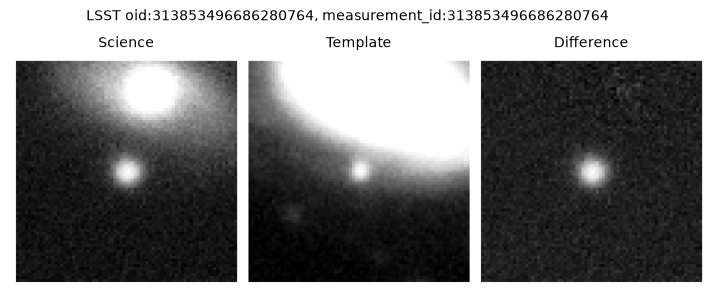

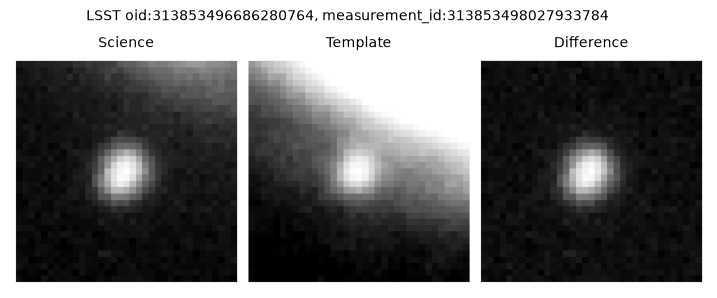

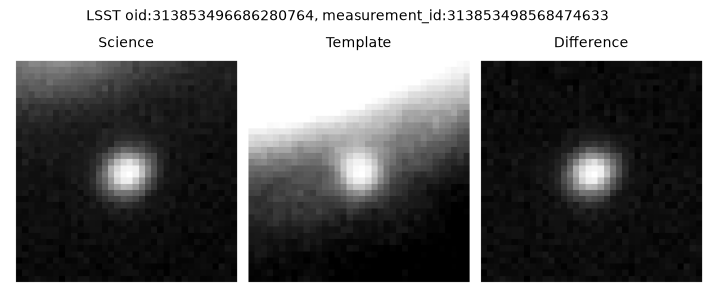

In [26]:
for i, row in df_dets_this.iterrows():
    params = {
        'survey': 'lsst',
        'oid': i,
        'measurement_id': row['measurement_id'],
    }
    df_stamps = alerce_client.plot_stamps(**params)

An extended use of the ALeRCE client to query stamps, including all cutout planes and headers (which include WCS) is presented in [this notebook](https://github.com/alercebroker/usecases/tree/master/notebooks/LSST/ALeRCE_LSST_Client_Queries.ipynb).

#### Latest diaObject information <a class='anchor' id='diaobject_latest'></a>

We query the latest record ingested by our pipeline for this object from the diaObject alert field as

In [27]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_dia_object
WHERE
    oid = %d
''' % oid
df_dia = tap_query(query)

display(df_dia)

,oid,validitystartmjdtai,ra,raerr,dec,decerr,ra_dec_cov,u_psffluxmean,u_psffluxmeanerr,u_psffluxsigma,u_psffluxndata,u_fpfluxmean,u_fpfluxmeanerr,g_psffluxmean,g_psffluxmeanerr,g_psffluxsigma,g_psffluxndata,g_fpfluxmean,g_fpfluxmeanerr,r_psffluxmean,r_psffluxmeanerr,r_psffluxsigma,r_psffluxndata,r_fpfluxmean,r_fpfluxmeanerr,i_psffluxmean,i_psffluxmeanerr,i_psffluxsigma,i_psffluxndata,i_fpfluxmean,i_fpfluxmeanerr,z_psffluxmean,z_psffluxmeanerr,z_psffluxsigma,z_psffluxndata,z_fpfluxmean,z_fpfluxmeanerr,y_psffluxmean,y_psffluxmeanerr,y_psffluxsigma,y_psffluxndata,y_fpfluxmean,y_fpfluxmeanerr,u_sciencefluxmean,u_sciencefluxmeanerr,g_sciencefluxmean,g_sciencefluxmeanerr,r_sciencefluxmean,r_sciencefluxmeanerr,i_sciencefluxmean,i_sciencefluxmeanerr,z_sciencefluxmean,z_sciencefluxmeanerr,y_sciencefluxmean,y_sciencefluxmeanerr,u_psffluxmin,u_psffluxmax,u_psffluxmaxslope,u_psffluxerrmean,g_psffluxmin,g_psffluxmax,g_psffluxmaxslope,g_psffluxerrmean,r_psffluxmin,r_psffluxmax,r_psffluxmaxslope,r_psffluxerrmean,i_psffluxmin,i_psffluxmax,i_psffluxmaxslope,i_psffluxerrmean,z_psffluxmin,z_psffluxmax,z_psffluxmaxslope,z_psffluxerrmean,y_psffluxmin,y_psffluxmax,y_psffluxmaxslope,y_psffluxerrmean,firstdiasourcemjdtai,lastdiasourcemjdtai,ndiasources,created_date
0,313853496686280764,61233.402914,9.35233,7.322068e-07,-42.462751,6.923263e-07,-9.582118e-15,NaN,NaN,NaN,0,NaN,NaN,30311.708984,62.198452,67637.414062,11,NaN,NaN,110478.46875,88.413109,21691.716797,20,NaN,NaN,59054.988281,90.054077,20440.267578,21,NaN,NaN,71975.890625,143.677597,4899.682617,20,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,33185.289062,63.105679,117845.867188,89.553978,70630.976562,91.743065,79263.015625,145.08847,NaN,NaN,NaN,NaN,NaN,NaN,1737.205322,175161.578125,616491.625,318.027405,76731.84375,153166.21875,3707192.5,417.217438,-3079.354004,103282.0625,4708704.0,470.657867,63671.414062,77870.992188,4686997.5,655.745483,NaN,NaN,NaN,NaN,NaN,NaN,72,2026-07-12


### Query a ssObject <a class='anchor' id='query_ssobject'></a>

We choose ```oid = ssObjectId = 21165806405629509```, which has the unpacked designation "2020 TE16"

In [28]:
oid = 21165806405629509
sid = 2

We query its main properties and light curve as before

In [29]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    oid = %d
    AND sid = %d
''' % (oid, sid)

df_obj = tap_query(query)
display(df_obj)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,21165806405629509,1,2,151.183383,1.910332,0.000002,0.000002,61094.120903,61098.272697,4.151794,91,0,0,2026-02-23,2026-02-27


In [30]:
query = '''
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.oid = %d
    AND det.sid = %d
''' % (oid, sid)
df_dets = tap_query(query)

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_dets.drop(columns=cols, inplace=True)
#display(df_dets)

In [31]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

In [32]:
display(df_dets)

,sid,measurement_id,mjd,ra,dec,band,created_date,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trailalgorithm,trail_flag,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,reliabilityversion,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,exposuretime,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name
oid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
21165806405629509,2,170046089996009515,61094.120903,151.668616,1.706979,3,2026-02-23,0,2026022200146,181,0,21165806405629509,0.000026,0.000032,-2.072009e-10,3327.888916,0.431156,1581.281494,0.597988,False,1699.175049,547.820679,False,False,False,8.144222,1833.400635,228.514908,NaN,1684.797852,1681,False,False,False,2123.717285,16.379791,151.668598,NaN,1.706993,NaN,1.530713,NaN,-0.962792,NaN,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1778.448364,220.138016,False,False,False,-16.749313,28.033731,0.125818,0.294704,-0.100408,0.268078,0.193955,-0.016782,False,False,False,False,0.045627,0.573673,,False,False,61094.122650,NaN,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i
21165806405629509,2,170046090132324364,61094.121367,151.668535,1.707034,3,2026-02-23,0,2026022200147,185,0,21165806405629509,0.000024,0.000025,-5.503898e-11,1303.993164,0.420428,269.183990,0.468560,False,1261.222778,569.349548,False,False,False,7.464016,1874.825195,245.177734,NaN,1643.801514,1681,False,False,False,2070.696289,10.576172,151.668532,NaN,1.707042,NaN,1.424796,NaN,19.212830,NaN,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1791.113159,230.847763,False,False,False,-49.262611,22.798962,0.302656,0.279428,-0.100698,0.301219,0.201256,-0.012052,False,False,False,False,0.146231,0.374304,,False,False,61094.123087,NaN,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i
21165806405629509,2,170046092939886678,61094.135633,151.665270,1.708348,1,2026-02-23,0,2026022200168,164,0,21165806405629509,0.000021,0.000034,3.272867e-11,380.551941,0.613806,3586.365479,0.380849,False,235.333450,253.030640,False,False,False,6.241818,770.311951,120.697449,NaN,1735.695190,1681,False,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,709.401245,118.343590,False,False,False,-82.854477,8.553704,NaN,NaN,NaN,0.298262,0.240823,0.029016,True,False,False,False,NaN,0.289569,,False,False,61094.137680,NaN,NaN,16,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,g
21165806405629509,2,170046101807169593,61094.173948,151.656393,1.711889,1,2026-02-23,0,2026022200234,181,0,21165806405629509,0.000032,0.000033,-4.918111e-11,2

#### Epoch data from the ssSource alert field, and latest mpc_orbits information <a class='anchor' id='tables_sso'></a>

We retrieve additional information for this object from the ssSource alert field, which is stored in our ```lsst_ss_detection``` table

In [33]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_ss_detection
WHERE
    ssObjectId = %d
''' % oid
df_ssd = tap_query(query)

display(df_ssd)

,measurement_id,ssobjectid,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
0,170063723605524549,21165806405629509,K20T16E,152.051960,-9.246543,237.442655,42.570323,168.853409,3.638510,1.363054e-08,0.0,2.016633e-08,0.001412,150.751254,2.095065,0.0,0.0,0.0,0.0,0.945613,0.925363,-0.194643,NaN,NaN,-1.803613e-08,8.900247e-09,1.471261e-09,-0.005126,-0.006708,-0.002905,0.010782,-1.188479e-08,6.655458e-09,4.983003e-10,0.001489,0.008249,0.003478,0.011761,1,2026-02-27
1,170050500789534739,21165806405629509,K20T16E,152.807675,-9.278414,238.316644,42.951882,170.431412,3.130459,1.358330e-08,0.0,2.013665e-08,0.001434,151.438348,1.802139,0.0,0.0,0.0,0.0,0.853850,0.766634,-0.375942,NaN,NaN,-1.792826e-08,9.039675e-09,1.531766e-09,-0.005217,-0.006662,-0.002897,0.010770,-1.192436e-08,6.491020e-09,4.271687e-10,0.002437,0.007898,0.003340,0.011432,1,2026-02-24
2,170050498379907088,21165806405629509,K20T16E,152.810164,-9.278412,238.319463,42.953215,170.434433,3.129483,1.358319e-08,0.0,2.013656e-08,0.001434,151.440595,1.801228,0.0,0.0,0.0,0.0,0.979069,0.953510,-0.222249,NaN,NaN,-1.792792e-08,9.040114e-09,1.531957e-09,-0.005217,-0.006662,-0.002897,0.010770,-1.192452e-08,6.490501e-09,4.269491e-10,0.002450,0.007887,0.003339,0.011420,1,2026-02-24
3,170050496896172060,21165806405629509,K20T16E,152.811784,-9.278484,238.321352,42.954021,170.436462,3.128829,1.358311e-08,0.0,2.013649e-08,0.001434,151.442109,1.800613,0.0,0.0,0.0,0.0,0.846815,0.795681,-0.289806,NaN,NaN,-1.792769e-08,9.040408e-09,1.532085e-09,-0.005217,-0.006662,-0.002897,0.010770,-1.192462e-08,6.490152e-09,4.268011e-10,0.002458,0.007879,0.003339,0.011411,1,2026-02-24
4,170050495695028255,21165806405629509,K20T16E,152.812833,-9.278490,238.322545,42.954577,170.437744,3.128415,1.358306e-08,0.0,2.013645e-08,0.001434,151.443068,1.800224,0.0,0.0,0.0,0.0,0.852845,0.821748,-0.228199,NaN,NaN,-1.792754e-08,9.040596e-09,1.532167e-09,-0.005218,-0.006662,-0.002897,0.010770,-1.192469e-08,6.489931e-09,4.267074e-10,0.002463,0.007874,0.003339,0.011405,1,2026-02-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86,170059304644116563,21165806405629509,K20T16E,152.294949,-9.258484,237.723653,42.692469,169.491165,3.433323,1.361312e-08,0.0,2.015677e-08,0.001419,150.971684,1.999504,0.0,0.0,0.0,0.0,0.933924,0.873390,-0.330763,NaN,NaN,-1.800143e-08,8.945462e-09,1.490855e-09,-0.005156,-0.006693,-0.002902,0.010778,-1.189580e-08,6.601635e-09,4.749733e-10,0.001759,0.008160,0.003435,0.011674,1,2026-02-26
87,170059305179938929,21165806405629509,K20T16E,152.294488,-9.258448,237.723109,42.692249,169.490051,3.433678,1.361316e-08,0.0,2.015679e-08,0.001419,150.971264,1.999680,0.0,0.0,0.0,0.0,0.934286,0.895214,-0.267363,NaN,NaN,-1.800150e-08,8.945379e-09,1.490819e-09,-0.005156,-0.006693,-0.002902,0.010778,-1.189577e-08,6.601737e-09,4.750162e-10,0.001756,0.008160,0.003435,0.011673,1,2026-02-26
88,170059306126278673,21165806405629509,K20T16E,152.293651,-9.258394,237.722129,42.691841,169.488052,3.434321,1.361321e-08,0.0,2.015682e-08,0.001419,150.970506,1.999997,0.0,0.0,0.0,0.0,0.925807,0.908405,-0.178662,NaN,NaN,-1.800161e-08,8.945228e-09,1.490753e-09,-0.005155,-0.006693,-0.002902,0.010778,-1.189574e-08,6.601921e-09,4.750936e-10,0.001750,0.008161,0.003436,0.011673,1,2026-02-26
89,170059308243877918,21165806405629509,K20T16E,152.289482,-9.258288,237.717372,42.689669,169.477982,3.437560,1.361350e-08,0.0,2.015699e-08,0.001419,150.966693,2.001597,0.0,0.0,0.0,0.0,0.968720,0.898580,-0.361902,NaN,NaN,-1.800220e-08,8.944468e-09,1.490424e-09,-0.005155,-0.006693,-0.002902,0.010778,-1.189554e-08,6

And also the latest mpc_orbits alert field information, stored in our ```lsst_mpc_orbits``` table

In [34]:
query = '''
SELECT
    *
FROM
    alerce_tap.lsst_mpc_orbits
WHERE
    ssObjectId = %d
''' % oid
df_mpc = tap_query(query)

display(df_mpc)

,ssobjectid,designation,packed_primary_provisional_designation,unpacked_primary_provisional_designation,mpc_orb_jsonb,created_at,updated_at,orbit_type_int,u_param,nopp,arc_length_total,arc_length_sel,nobs_total,nobs_total_sel,a,q,e,i,node,argperi,peri_time,yarkovsky,srp,a1,a2,a3,dt,mean_anomaly,period,mean_motion,a_unc,q_unc,e_unc,i_unc,node_unc,argperi_unc,peri_time_unc,yarkovsky_unc,srp_unc,a1_unc,a2_unc,a3_unc,dt_unc,mean_anomaly_unc,period_unc,mean_motion_unc,epoch_mjd,h,g,not_normalized_rms,normalized_rms,earth_moid,fitting_datetime,created_date,updated_date
0,21165806405629509,2020 TE16,K20T16E,2020 TE16,"{""CAR"": {""covariance"": {""cov00"": 0.00000000002690110152166777, ""cov01"": 0.0000000000102575724806...",1970-01-01,1970-01-01,-1,0,4,0.0,0.0,63,63,0.0,1.925311,0.242377,6.321986,234.830867,130.788252,60558.180433,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000005,0.000002,0.000042,0.000197,0.000525,0.001386,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60600.0,19.474,0.15,0.0,0.637635,0.9307,1970-01-01,2026-02-27,2026-02-27


We show its detections coordinates in different systems, colored by MJD and difference flux. For this we define a function and merge epoch tables

In [35]:
def plot_scatter(df=None, title='', prop_x=None, prop_y=None,
                 prop_color=None, figsize=(6, 3), alpha=0.7):
    fontsize = 9
    plt.rcParams.update({'font.size': fontsize})
    
    fig, ax = plt.subplots(figsize=figsize)

    if prop_color is None:
        sc = ax.scatter(df[prop_x], df[prop_y], s=3, alpha=alpha)
    else:
        cmap = 'coolwarm'
        sc = ax.scatter(df[prop_x], df[prop_y],
                        c=df[prop_color],
                        cmap=cmap, s=10, alpha=alpha)
        plt.colorbar(sc, ax=ax, label=prop_color)
    
    ax.set_xlabel(prop_x)
    ax.set_ylabel(prop_y)
    ax.set_title(title)
    
    plt.tight_layout()
    plt.rcParams.update({'font.size': 12})

In [36]:
cols = ['ssObjectId', 'measurement_id']
cols = [x.lower() for x in cols]

df_dets_sso = pd.merge(df_dets.reset_index(), df_ssd,
                       on=cols)
col = 'created_date'
df_dets_sso = df_dets_sso.drop(
    columns=[col + '_x']).rename(columns={col + '_y': col}).copy()
del df_dets, df_ssd

display(df_dets_sso)

,oid,sid,measurement_id,mjd,ra,dec,band,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trailalgorithm,trail_flag,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,reliabilityversion,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,exposuretime,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name,designation,ecllambda,eclbeta,gallon,gallat,elongation,phaseangle,toporange,toporangerate,heliorange,heliorangerate,ephra,ephdec,ephvmag,ephrate,ephratera,ephratedec,ephoffset,ephoffsetra,ephoffsetdec,ephoffsetalongtrack,ephoffsetcrosstrack,helio_x,helio_y,helio_z,helio_vx,helio_vy,helio_vz,helio_vtot,topo_x,topo_y,topo_z,topo_vx,topo_vy,topo_vz,topo_vtot,diadistancerank,created_date
0,21165806405629509,2,170046089996009515,61094.120903,151.668616,1.706979,3,0,2026022200146,181,0,21165806405629509,0.000026,0.000032,-2.072009e-10,3327.888916,0.431156,1581.281494,0.597988,False,1699.175049,547.820679,False,False,False,8.144222,1833.400635,228.514908,NaN,1684.797852,1681,False,False,False,2123.717285,16.379791,151.668598,NaN,1.706993,NaN,1.530713,NaN,-0.962792,NaN,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1778.448364,220.138016,False,False,False,-16.749313,28.033731,0.125818,0.294704,-0.100408,0.268078,0.193955,-0.016782,False,False,False,False,0.045627,0.573673,,False,False,61094.122650,NaN,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i,K20T16E,153.059685,-9.285809,238.608336,43.080044,170.656433,3.058232,1.357201e-08,0.0,2.012674e-08,0.001440,151.668381,1.707074,0.0,0.0,0.0,0.0,0.911854,0.844816,-0.343167,NaN,NaN,-1.789218e-08,9.085569e-09,1.551737e-09,-0.005247,-0.006647,-0.002895,0.010766,-1.194100e-08,6.438067e-09,4.043056e-10,0.002723,0.007754,0.003290,0.011299,1,2026-02-23
1,21165806405629509,2,170046090132324364,61094.121367,151.668535,1.707034,3,0,2026022200147,185,0,21165806405629509,0.000024,0.000025,-5.503898e-11,1303.993164,0.420428,269.183990,0.468560,False,1261.222778,569.349548,False,False,False,7.464016,1874.825195,245.177734,NaN,1643.801514,1681,False,False,False,2070.696289,10.576172,151.668532,NaN,1.707042,NaN,1.424796,NaN,19.212830,NaN,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1791.113159,230.847763,False,False,False,-49.262611,22.798962,0.302656,0.279428,-0.100698,0.301219,0.201256,-0.012052,False,False,False,False,0.146231,0.374304,,False,False,61094.123087,NaN,NaN,19,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i,K20T16E,153.059588,-9.285786,238.608208,43.080012,170.656372,3.058254,1.357202e-08,0.0,2.012674e-08,0.001440,151.668275,1.707117,0.0,0.0,0.0,0.0,0.980570,0.934575,-0.296797,NaN,NaN,-1.789220e-08,9.085548e-09,1.551728e-09,-0.005247,-0.006647,-0.002895,0.010766,-1.19409

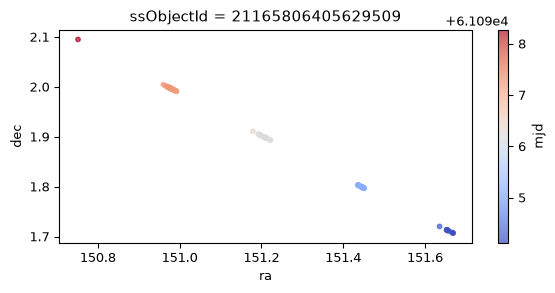

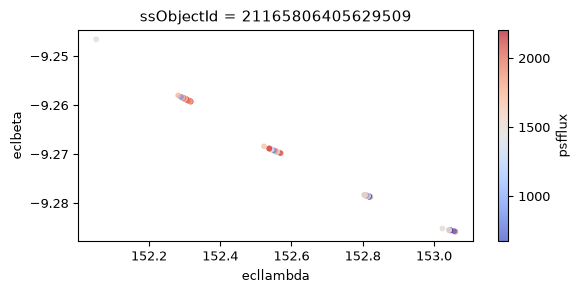

In [37]:
props_x = ['ra', 'eclLambda']
props_x = [x.lower() for x in props_x]
props_y = ['dec', 'eclBeta']
props_y = [x.lower() for x in props_y]
props_color = ['mjd', 'psfFlux']
props_color = [x.lower() for x in props_color]
title = 'ssObjectId = ' + str(oid)

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_dets_sso, title=title,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color)

### Cone search <a class='anchor' id='conesearch'></a>

Let us say we want to know if the known RRLab star SSS_J004408.1-432806 has triggered Rubin alerts. This star has equatorial coordinates (11.03301, -43.46871) deg and a period of 0.546472 d in VSX (see https://vsx.aavso.org/index.php?view=detail.top&oid=479455). We use a cone search with a small radius (e.g. 1.5 arcsec)

In [38]:
ra = 11.03301
dec = -43.46871
period = 0.546472
radius = 1.5

Note that you need to provide both object coordinates (equatorial system) and search radius in deg

In [39]:
query = '''
SELECT
    *
FROM
    alerce_tap.object AS o
WHERE
    tid = %d
    AND CONTAINS(POINT('ICRS', o.meanra, o.meandec),
                 CIRCLE('ICRS', %.7g, %.7g, %g)) = 1
''' % (tid, ra, dec, radius / 3600.)

df_obj = tap_query(query)
df_obj

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,313629129709715483,1,1,11.03329,-43.468726,3.745349e-07,3.671554e-07,60973.170251,61235.404704,262.234452,62,32,0,2026-02-13,2026-07-14


Now that we know the object identifier in LSST (and its ```sid```) we can query other data as before. In particular, we obtain its light curve and show it also as a folded light curve using the known period

In [40]:
oid = df_obj.iloc[0]['oid']
sid = df_obj.iloc[0]['sid']

In [41]:
query = '''
SELECT
    det.*,
    lsst_det.*
FROM
    alerce_tap.detection AS det
JOIN
    alerce_tap.lsst_detection AS lsst_det
ON
    det.oid = lsst_det.oid
    AND det.sid = lsst_det.sid
    AND det.measurement_id = lsst_det.measurement_id
WHERE
    det.oid = %d
''' % oid
df_dets = tap_query(query)

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_dets.drop(columns=cols, inplace=True)
#display(df_dets)

In [42]:
query = '''
SELECT
    forced.*,
    lsst_forced.*
FROM
    alerce_tap.forced_photometry AS forced
JOIN
    alerce_tap.lsst_forced_photometry AS lsst_forced
ON
    forced.oid = lsst_forced.oid
    AND forced.sid = lsst_forced.sid
    AND forced.measurement_id = lsst_forced.measurement_id
WHERE
    forced.oid = %d
    AND forced.sid = %d
''' % (oid, sid)
df_forced = tap_query(query)

cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
df_forced.drop(columns=cols, inplace=True)
#display(df_forced)

In [43]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)

df_forced = add_mapped_column(
    df=df_forced,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)

In [44]:
display(df_dets)

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,parentdiasourceid,visit,detector,diaobjectid,ssobjectid,raerr,decerr,ra_dec_cov,x,xerr,y,yerr,centroid_flag,apflux,apfluxerr,apflux_flag,apflux_flag_aperturetruncated,isnegative,snr,psfflux,psffluxerr,psflnl,psfchi2,psfndata,psfflux_flag,psfflux_flag_edge,psfflux_flag_nogoodpixels,trailflux,trailfluxerr,trailra,trailraerr,traildec,traildecerr,traillength,traillengtherr,trailangle,trailangleerr,trailchi2,trailndata,trailalgorithm,trail_flag,trail_flag_edge,dipolemeanflux,dipolemeanfluxerr,dipolefluxdiff,dipolefluxdifferr,dipolelength,dipoleangle,dipolechi2,dipolendata,scienceflux,sciencefluxerr,forced_psfflux_flag,forced_psfflux_flag_edge,forced_psfflux_flag_nogoodpixels,templateflux,templatefluxerr,ixx,iyy,ixy,ixxpsf,iyypsf,ixypsf,shape_flag,shape_flag_no_pixels,shape_flag_not_contained,shape_flag_parent_source,extendedness,reliability,reliabilityversion,isdipole,dipolefitattempted,timeprocessedmjdtai,timewithdrawnmjdtai,exposuretime,bboxsize,pixelflags,pixelflags_bad,pixelflags_cr,pixelflags_crcenter,pixelflags_edge,pixelflags_nodata,pixelflags_nodatacenter,pixelflags_interpolated,pixelflags_interpolatedcenter,pixelflags_offimage,pixelflags_saturated,pixelflags_saturatedcenter,pixelflags_suspect,pixelflags_suspectcenter,pixelflags_streak,pixelflags_streakcenter,pixelflags_injected,pixelflags_injectedcenter,pixelflags_injected_template,pixelflags_injected_templatecenter,glint_trail,has_stamp,band_name
0,313629129709715483,1,170587116609732722,61217.416228,11.033261,-43.468719,3,2026-06-26,0,2026062500645,25,313629129709715483,0,0.000001,0.000001,-6.455706e-14,348.964783,0.023316,3254.197998,0.022351,False,42371.878906,627.316406,False,False,False,102.795944,40800.164062,390.777222,NaN,2486.893066,1681,False,False,False,33962.097656,408.788177,11.033261,NaN,-43.468719,NaN,0.346262,0.080995,96.155502,13.790262,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,138784.828125,415.628571,False,False,False,96041.781250,125.294762,0.107856,0.101837,-0.004331,0.098843,0.088932,-0.001170,False,False,False,False,0.031507,0.999905,,False,False,61217.418586,NaN,NaN,24,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,i
1,313629129709715483,1,170595944914485287,61219.422467,11.033311,-43.468733,1,2026-06-28,0,2026062700885,24,313629129709715483,0,0.000009,0.000009,-4.753430e-13,3173.403320,0.167469,262.411652,0.166698,False,-11393.942383,593.734192,False,False,True,30.240448,-11971.864258,392.591766,NaN,1715.764526,1681,False,False,False,-11173.576172,304.221191,11.033311,NaN,-43.468733,NaN,0.293380,1.025684,65.369804,201.505859,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,66784.117188,409.570862,False,False,False,79181.804688,9.465317,0.357893,0.363953,-0.001962,0.435012,0.414368,0.001033,False,False,False,False,0.213024,0.812284,,False,False,61219.424116,NaN,NaN,36,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,g
2,313629129709715483,1,170595945045033006,61219.422929,11.033320,-43.468739,1,2026-06-28,0,2026062700886,17,313629129709715483,0,0.000009,0.000009,3.306157e-12,1798.480713,0.149785,1078.805786,0.156934,False,-11236.511719,590.200195,False,False,True,31.055981,-12225.179688,388.545197,NaN,1763.886230,1681,False,False,False,-12115.952148,187.298004,11.033320,NaN,-43.468740,NaN,1.241521,0.178249,85.357613,9.128689,NaN,0,<NA>,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,66231.867188,404.227722,False,False,False,78882.796875,9.357190,0.322334,0.342218,-0.071818,0.414511,0.412209,-0.002621,False,False,False,False,0.328164,0.812703,,False,False,61219.424526,NaN,NaN,35,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,g
3,313629129709715483,1,170604740730683475,61221.417075,11.033095,-43.468658,3,2026-06-30,0,2026062900883,8,31362912970971548

In [45]:
display(df_forced)

,oid,sid,measurement_id,mjd,ra,dec,band,created_date,visit,detector,psfflux,psffluxerr,scienceflux,sciencefluxerr,timeprocessedmjdtai,timewithdrawnmjdtai,band_name
0,313629129709715483,1,170525524261077001,61203.444230,11.033299,-43.468731,3,2026-06-26,2026061100498,87,-4969.399902,2865.931641,91120.328125,2922.761963,61203.445894,NaN,i
1,313629129709715483,1,170587116609732611,61217.416228,11.033293,-43.468727,3,2026-06-26,2026062500645,25,40701.101562,396.928711,137918.656250,414.050720,61217.418760,NaN,i
2,313629129709715483,1,170587116743950340,61217.416705,11.033293,-43.468727,3,2026-06-28,2026062500646,25,41672.761719,407.224762,138858.671875,418.846558,61217.419122,NaN,i
3,313629129709715483,1,170587117164429317,61217.420025,11.033293,-43.468727,1,2026-06-28,2026062500649,59,71139.242188,333.533264,151056.390625,339.898254,61217.421649,NaN,g
4,313629129709715483,1,170587117303889927,61217.420491,11.033293,-43.468727,1,2026-06-28,2026062500650,69,69380.882812,330.436859,149709.296875,337.859680,61217.422288,NaN,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,313629129709715483,1,170657517555679249,61233.401480,11.033292,-43.468727,1,2026-07-14,2026071100885,5,7834.608887,284.467041,87038.140625,281.000092,61233.403140,NaN,g
28,313629129709715483,1,170666301987487750,61235.401875,11.033292,-43.468727,3,2026-07-14,2026071300798,35,27573.656250,510.231323,124508.726562,509.994171,61235.404135,NaN,i
29,313629129709715483,1,170666302120132614,61235.402309,11.033292,-43.468727,3,2026-07-14,2026071300799,32,27707.355469,573.862610,124297.218750,576.050476,61235.404632,NaN,i
30,313629129709715483,1,170666302240718855,61235.404269,11.033291,-43.468726,1,2026-07-14,2026071300800,6,59341.804688,485.837982,137968.328125,483.532410,61235.406018,NaN,g


In [46]:
lc_params = {
    'from_tap': True,
    'use_mag': False,
    'use_flux': True,
    'show_yr': False,
    'figwidth': 8,
    'pheight': 3,
    'fontsize': 9,
    'alpha': 0.5,
}

In [47]:
df_dets.set_index('oid', inplace=True)
if len(df_forced) > 0:
    df_forced.set_index('oid', inplace=True)

epochs = {
    'detections': df_dets,
    'forced_photometry': df_forced,

}
d_objs = ms.group_data_sid_oid(
    sid=sid,
    oid=oid,
    df_dets=epochs['detections'].copy(),
    df_forced=epochs['forced_photometry'].copy() \
        if oid in epochs['forced_photometry'].index else pd.DataFrame(),
        lc_kwargs=ms.init_lc_kwargs()
    )

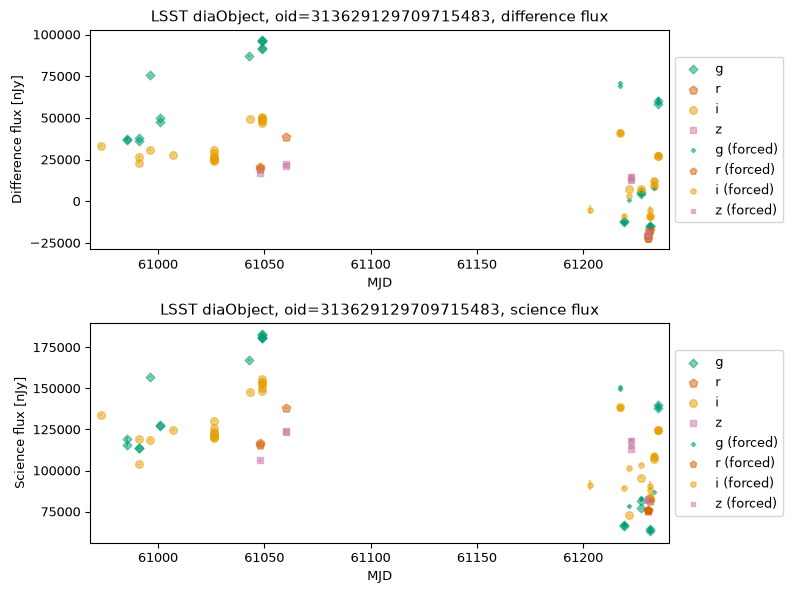

In [48]:
d_objs[sid][oid]['lc_kwargs']['show_forced'] = True

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

/home/ammunoz1/.local/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


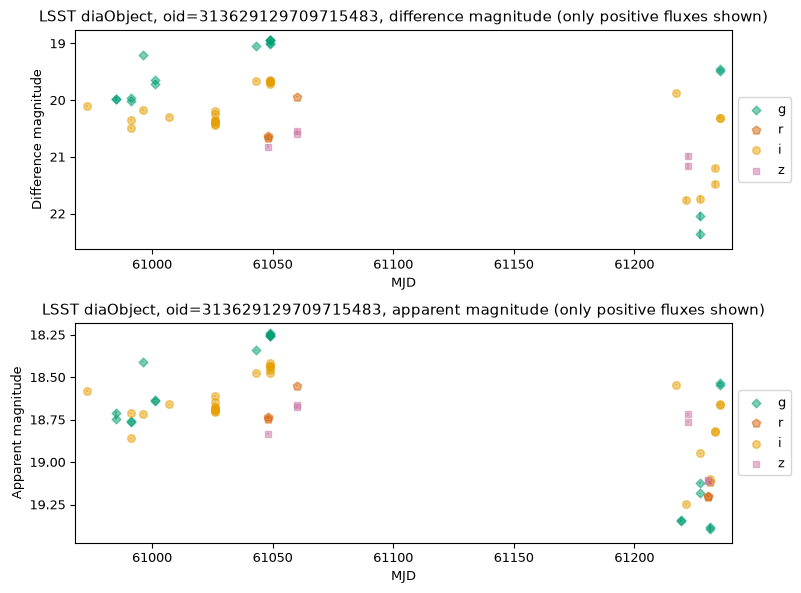

In [49]:
d_objs[sid][oid]['lc_kwargs']['show_flux'] = False
d_objs[sid][oid]['lc_kwargs']['show_forced'] = False

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

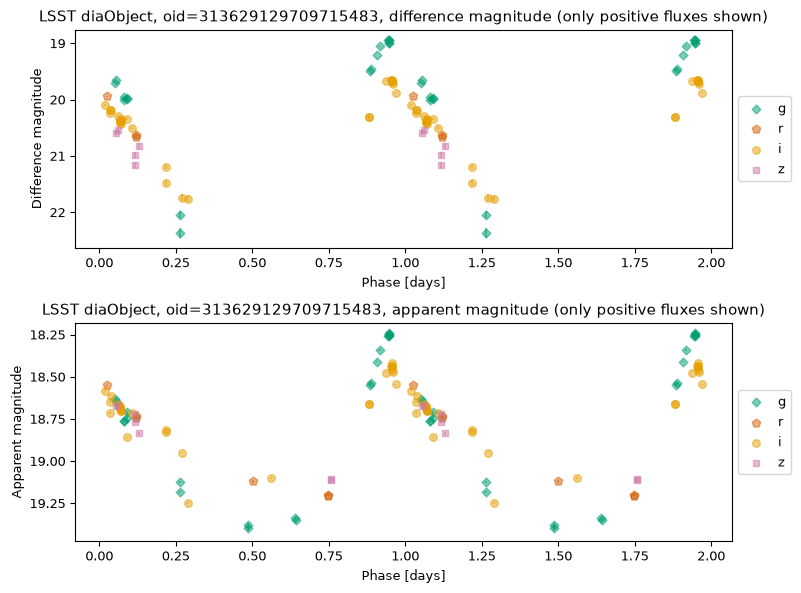

In [50]:
d_objs[sid][oid]['lc_kwargs']['show_folded'] = True
d_objs[sid][oid]['lc_kwargs']['folded_period'] = period

ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

## Querying samples of objects <a class='anchor' id='query_many'></a>

The ALeRCE pipeline computes probabilities for different classifiers. At this time, we classify LSST objects using the ALeRCE stamp classifier (still in beta mode); a first model was stamp_classifier_rubin_beta version 2.0.1, while the latest model is stamp_classifier_rubin_beta_20260421 version 2.0.2. These are deep learning classifiers based on each object's first alert image cutouts (manuscript in preparation; see [Carrasco-Davis et al. 2021](https://ui.adsabs.harvard.edu/abs/2021AJ....162..231C/abstract) for a similar version using the ZTF public alert stream). Both have classified all Rubin objects, with the latest model using a more up-to-date training set. The stamp classifier taxonomy includes five classes, and is used to pre-select transient candidates (e.g. supernovae, tidal disruption events) early after their first light.

Note that we use integer identifiers for both classifiers and their taxonomies. We recover the classifier and class names using the mapping defined in the ```classifier``` and ```taxonomy``` LUTs, respectively:

In [51]:
table_name = 'classifier'

query = '''
SELECT
    classifier_id, classifier_name, classifier_version, tid
FROM
    alerce_tap.%s
WHERE
    tid = %d
''' % (table_name, tid)

df_classifiers = tap_query(query)
display(df_classifiers)

,classifier_id,classifier_name,classifier_version,tid
0,1,stamp_classifier_rubin_beta,2.0.1,1
1,3,stamp_classifier_rubin_beta_20260421,2.0.2,1


In [52]:
classifier_id = 3 # Stamp classifier (latest model)

In [53]:
table_name = 'taxonomy'

query = '''
SELECT
    class_id, class_name, classifier_id
FROM
    alerce_tap.%s
WHERE
    classifier_id = %d
''' % (table_name, classifier_id)

df_tax_stamp = tap_query(query)
display(df_tax_stamp)

,class_id,class_name,classifier_id
0,0,SN,3
1,1,AGN,3
2,2,VS,3
3,3,asteroid,3
4,4,bogus,3


We search for 15 objects that had their first detection between Mar 1 2026 and June 27 2026, their last detection after Mar 10 2026, have 30 detections or more, and have the highest probability of being a supernova (SN) according to the latest stamp classifier, as

In [54]:
def utc_to_mjd(time):
    return Time(time, format='isot', scale='utc').mjd

In [55]:
firstmjd_min = utc_to_mjd('2026-03-01T00:00:00')
firstmjd_max = utc_to_mjd('2026-06-27T00:00:00')
print(firstmjd_min, firstmjd_max)

lastmjd_min = utc_to_mjd('2026-03-10T00:00:00')
print(lastmjd_min)

class_id = 0 # SN
n_det_min = 30
n_objs = 15

61100.0 61218.0
61109.0


In [56]:
query = '''
SELECT TOP %d
    obj.*,
    prob.*
FROM
    alerce_tap.object AS obj
JOIN
    alerce_tap.probability AS prob
ON
    obj.oid = prob.oid
    AND obj.sid = prob.sid
WHERE
    obj.firstmjd >= %g
    AND obj.firstmjd < %g
    AND obj.lastmjd >= %g
    AND obj.n_det >= %d
    AND prob.classifier_id = %d
    AND prob.class_id = %d
    AND prob.ranking = 1
ORDER BY prob.probability DESC
''' % (n_objs,
       firstmjd_min, firstmjd_max,
       lastmjd_min, n_det_min,
       classifier_id, class_id)
df_objs = tap_query(query)

cols = ['oid_', 'sid_', 'lastmjd_']
df_objs.drop(columns=cols, inplace=True)

We recover both classifier and class names as

In [57]:
df_objs = add_mapped_column(
    df=df_objs,
    df_lut=df_classifiers,
    col='classifier_id',
    col_mapped='classifier_name'
)

df_objs = add_mapped_column(
    df=df_objs,
    df_lut=df_tax_stamp,
    col='class_id',
    col_mapped='class_name'
)

In [58]:
display(df_objs)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date,classifier_id,classifier_version,class_id,probability,ranking,classifier_name,class_name
0,170094456365121569,1,1,150.842813,2.963688,8.342428e-07,8.314584e-07,61105.095334,61189.036344,83.941010,68,181,0,2026-03-06,2026-05-29,3,202,0,0.986570,1,stamp_classifier_rubin_beta_20260421,SN
1,170226393632735260,1,1,149.979878,0.537539,8.241714e-07,8.577625e-07,61135.002822,61178.983683,43.980862,60,79,0,2026-04-05,2026-05-18,3,202,0,0.985418,1,stamp_classifier_rubin_beta_20260421,SN
2,170107660764446767,1,1,151.576121,1.848071,8.574231e-07,8.736672e-07,61108.085916,61204.973907,96.887990,94,175,0,2026-03-09,2026-06-13,3,202,0,0.980048,1,stamp_classifier_rubin_beta_20260421,SN
3,170389126977683571,1,1,150.212951,2.713226,1.522382e-06,1.546876e-06,61172.002308,61204.973907,32.971599,40,74,0,2026-05-13,2026-06-13,3,202,0,0.967129,1,stamp_classifier_rubin_beta_20260421,SN
4,170389126953566274,1,1,149.907399,2.609188,9.882865e-07,9.704551e-07,61172.002308,61204.981752,32.979444,57,81,0,2026-05-13,2026-06-13,3,202,0,0.959600,1,stamp_classifier_rubin_beta_20260421,SN
5,170226393570345033,1,1,148.788193,2.670862,9.733727e-07,9.880083e-07,61135.002822,61152.083609,17.080787,49,80,0,2026-04-05,2026-04-22,3,202,0,0.958356,1,stamp_classifier_rubin_beta_20260421,SN
6,170226393351716950,1,1,150.403671,3.103615,8.943046e-07,8.960108e-07,61134.999535,61204.973907,69.974372,76,177,0,2026-04-05,2026-06-13,3,202,0,0.951708,1,stamp_classifier_rubin_beta_20260421,SN
7,170411112000913487,1,1,151.163536,2.507444,4.168477e-07,4.176062e-07,61176.986842,61205.983739,28.996897,67,82,0,2026-05-16,2026-06-14,3,202,0,0.947267,1,stamp_classifier_rubin_beta_20260421,SN
8,170261592629837872,1,1,151.134202,3.315060,3.340845e-07,3.360418e-07,61143.054629,61204.981235,61.926606,73,131,0,2026-04-13,2026-06-13,3,202,0,0.945664,1,stamp_classifier_rubin_beta_20260421,SN
9,170226393301385313,1,1,148.720919,2.580764,1.159545e-06,1.205134e-06,61134.999535,61204.973907,69.974372,85,169,0,2026-04-05,2026-06-13,3,202,0,0.939747,1,stamp_classifier_rubin_beta_20260421,SN


Note that for each object we compute probabilities in all taxonomy classes, but in this query we were interested only in their most likely class, thus we asked for ```ranking = 1``` probabilities only.

We display their mean coordinates, as well as some of their properties

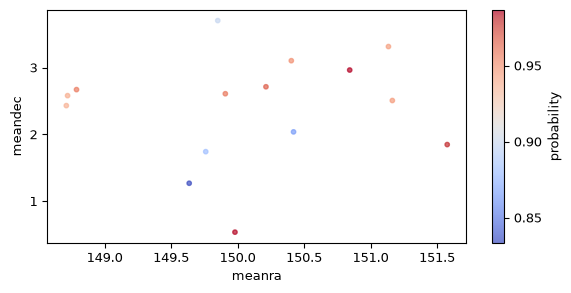

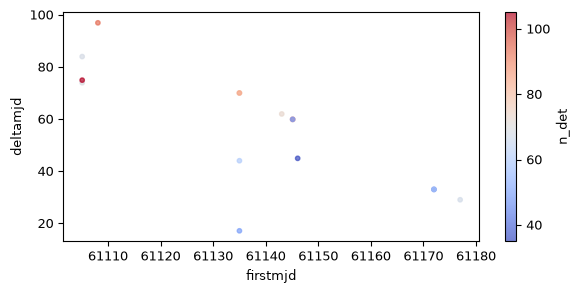

In [59]:
props_x = ['meanra', 'firstmjd']
props_x = [x.lower() for x in props_x]
props_y = ['meandec', 'deltamjd']
props_y = [x.lower() for x in props_y]
props_color = ['probability', 'n_det']
props_color = [x.lower() for x in props_color]

for (prop_x, prop_y, prop_color) in zip(
    props_x, props_y, props_color):
    plot_scatter(df=df_objs,
                 prop_x=prop_x, prop_y=prop_y,
                 prop_color=prop_color)

### Generate an ALeRCE LSST Explorer link <a class='anchor' id='explorer_url'></a>

Note that the interface accepts a maximum of 200 objects

In [60]:
def print_link_lsst(index=None, classifier='stamp_classifier_rubin_beta_20260421'):
    if len(index) == 1:
        expr = 'https://lsst.alerce.online/object/' + str(index[0]) \
               + '?survey=lsst'
    else:
        expr1 = 'https://lsst.alerce.online/?oid='
        expr2 = ','.join(list([str(x) for x in index]))
        expr3 = '&survey=lsst'
        expr4 = '&classifier=' + classifier + '&page=1'
        expr = expr1 + expr2 + expr3 + expr4
    
    display(HTML("<a href='%s' target=\"_blank\"> %s <a>" % (expr, expr)))

In [61]:
print_link_lsst(index=df_objs['oid'])

### Object lists <a class='anchor' id='query_list'></a>

Note that we can also search by a list of known object identifiers

In [62]:
sid = 1
oids = [
    313853517490028563,
    313695087485255753,
    313853517444939794,
]

In [63]:
query = '''
SELECT
    *
FROM
    alerce_tap.object
WHERE
    sid = %d
    AND oid IN (%s)
''' % (sid, ','.join(["'%s'" % oid for oid in oids]))

df_objs = tap_query(query)
display(df_objs)

,oid,tid,sid,meanra,meandec,sigmara,sigmadec,firstmjd,lastmjd,deltamjd,n_det,n_forced,n_non_det,created_date,updated_date
0,313853517444939794,1,1,149.738956,2.220690,1.513282e-07,1.523100e-07,61024.245933,61205.988991,181.743059,1403,1217,0,2026-02-13,2026-06-14
1,313853517490028563,1,1,150.021002,0.550432,2.737409e-07,2.781927e-07,61024.245933,61204.981752,180.735819,809,697,0,2026-02-13,2026-06-13
2,313695087485255753,1,1,10.240453,-43.631762,8.784008e-07,8.479267e-07,60988.123073,61235.404704,247.281630,166,32,0,2026-02-13,2026-07-14


We generate their Explorer link

In [64]:
index = [oid for oid in oids if oid in df_objs['oid'].tolist()]
print_link_lsst(index=index)

### Querying detections for larger samples <a class='anchor' id='query_detections_many'></a>

We query the detections for all these objects altogether. For this we define a function that splits the call in smaller chunks, useful for longer object lists

In [65]:
def find_detections(chunk_size=100, index=None, sid=None,
                    maxrec = int(5e5)):
    bin_ids = np.arange(int(np.ceil(len(index) / chunk_size)))
    #print(str(len(bin_ids)) + ' chunks')
    df = pd.DataFrame()
    
    for idx in bin_ids:
        #print('Chunk ' + str(idx))
        index_i = idx * chunk_size
        index_f = (idx + 1) * chunk_size
        names = np.array(index)[index_i:index_f].tolist()
        
        query = '''
        SELECT
            det.*,
            lsst_det.*
        FROM
            alerce_tap.detection AS det
        JOIN
            alerce_tap.lsst_detection AS lsst_det
        ON
            det.oid = lsst_det.oid
            AND det.sid = lsst_det.sid
            AND det.measurement_id = lsst_det.measurement_id
        WHERE
            det.sid = %d
            AND lsst_det.oid IN (%s)
        ''' % (sid, ','.join(["'%s'" % oid for oid in names]))
        df_aux = tap_query(query)
        
        cols = ['oid_', 'sid_', 'measurement_id_', 'created_date_']
        df_aux.drop(columns=cols, inplace=True)

        df = pd.concat([df, df_aux], axis=0)
        del df_aux

    return df

In [66]:
index = df_objs['oid']
df_dets = find_detections(index=index, sid=sid)

In [67]:
df_dets = add_mapped_column(
    df=df_dets,
    df_lut=df_bands,
    col='band',
    col_mapped='band_name'
)
df_dets.set_index('oid', inplace=True)

In [68]:
display(df_dets[cols_lc])

,sid,measurement_id,band_name,mjd,psfflux,psffluxerr,scienceflux,sciencefluxerr
oid,,,,,,,,
313695087485255753,1,170587116622839914,i,61217.416228,3551.265625,199.919403,12504.946289,203.638992
313695087485255753,1,170587116757057553,i,61217.416705,3087.271240,202.279221,12116.286133,206.640472
313695087485255753,1,170587117164953615,g,61217.420025,4515.137695,113.958031,11418.931641,116.496201
313695087485255753,1,170587117320142888,g,61217.420491,4394.005371,110.988388,11361.627930,115.479645
313695087485255753,1,170595944388100122,i,61219.418592,3838.871582,430.406006,14293.249023,449.548279
...,...,...,...,...,...,...,...,...
313853517490028563,1,314011776892534797,z,61060.298492,4638.598633,379.880798,20550.980469,362.704407
313853517490028563,1,314011777026752530,z,61060.298890,5069.586914,383.087738,20808.773438,367.057953
313853517490028563,1,314011777160970253,z,61060.299997,4385.311035,357.484863,20088.320312,343.792053


We show the light curves using flux densities and magnitudes

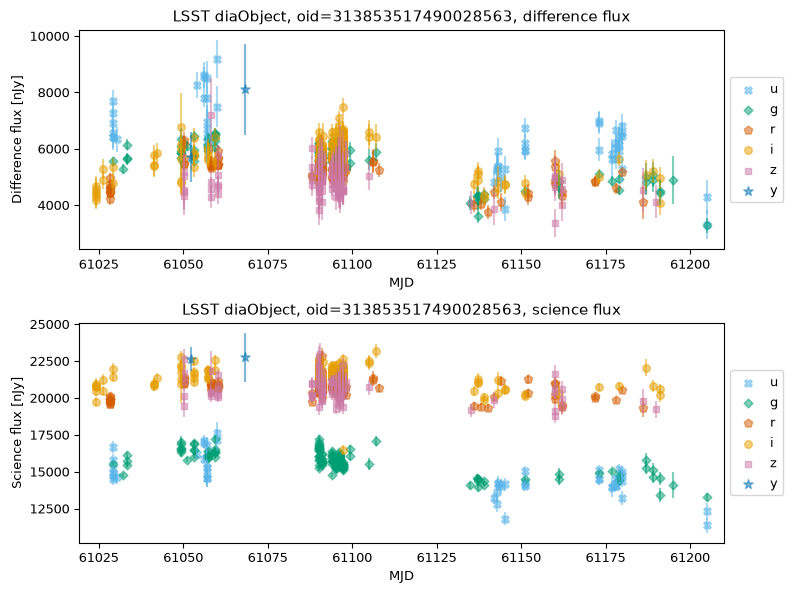

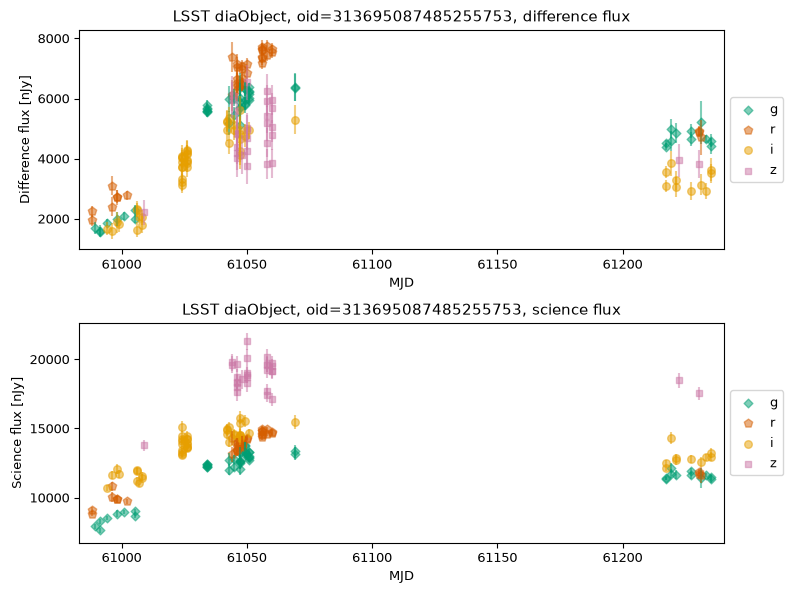

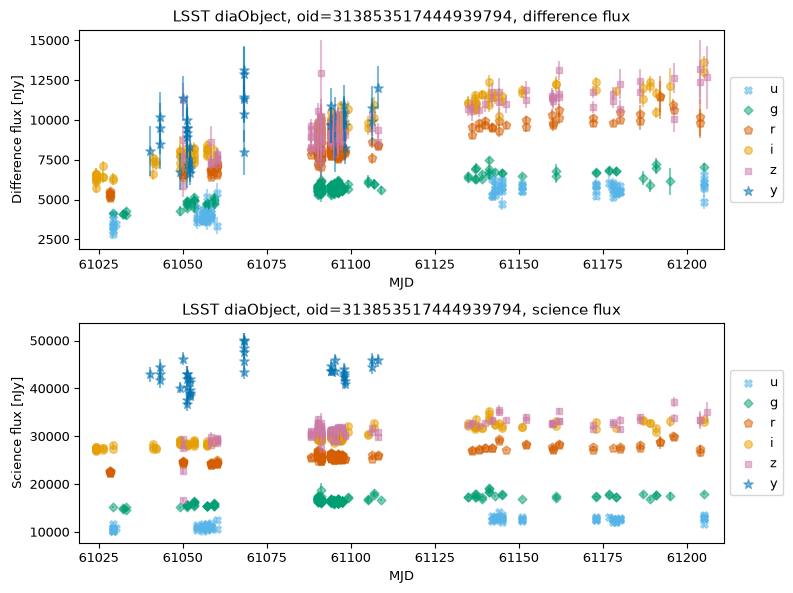

In [69]:
for oid in oids:
    d_objs = ms.group_data_sid_oid(
        sid=sid,
        oid=oid,
        df_dets=df_dets.loc[oid].copy(),
        lc_kwargs=ms.init_lc_kwargs()
    )
    ms.plot_lc(d_objs=d_objs, lc_params=lc_params)

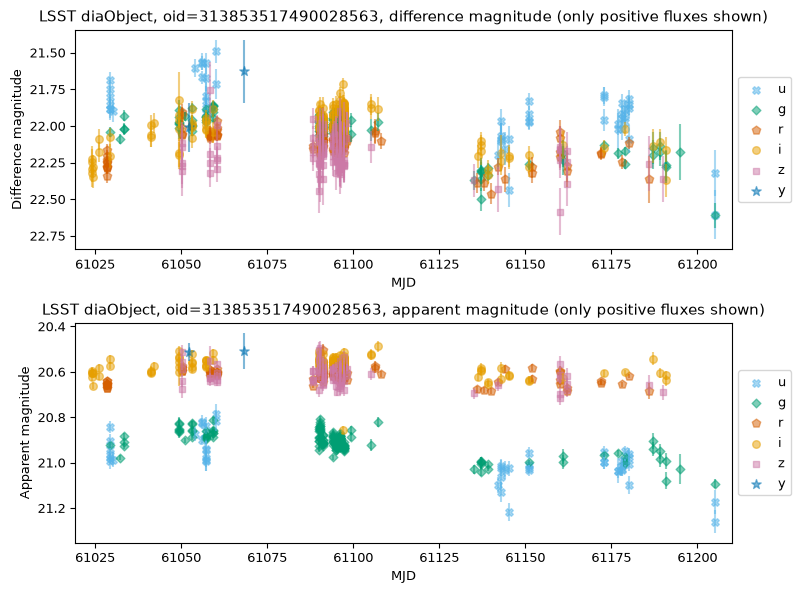

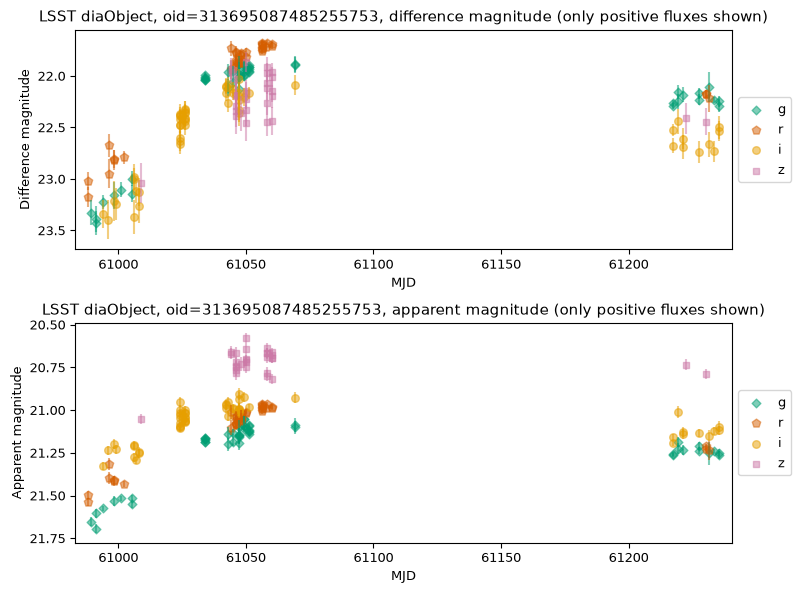

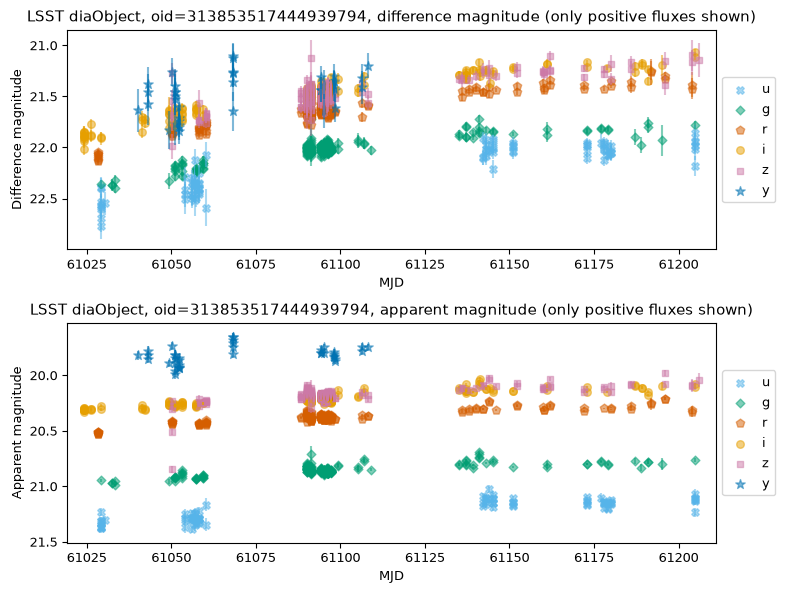

In [70]:
for oid in oids:
    d_objs = ms.group_data_sid_oid(
        sid=sid,
        oid=oid,
        df_dets=df_dets.loc[oid].copy(),
        lc_kwargs=ms.init_lc_kwargs()
    )
    d_objs[sid][oid]['lc_kwargs']['show_flux'] = False
    ms.plot_lc(d_objs=d_objs, lc_params=lc_params)